# Heart Disease — Exploratory Data Analysis

**Dataset:** UCI Heart Disease (cleaned 14-feature version)
**Objective:** assess data quality, understand distributions, and identify meaningful
relationships with heart disease.

> **Important:** this notebook is an exploratory analysis, not a clinical or diagnostic
> assessment. Statistical associations do not imply causation.

## Executive Summary

This analysis is organized around four questions:

1. How are the main clinical variables distributed?
2. Which features show the clearest relationship with heart disease presence?
3. Are those relationships supported by statistical tests and effect sizes?
4. Which findings are worth carrying forward into a predictive modeling workflow?

## Contents

1. Import Libraries and Visual Settings
2. Data Loading & Overview
3. Data Quality & Cleaning
4. Data Dictionary & Feature Types
5. Descriptive Statistics
6. Outlier Detection (IQR Method)
7. Target Analysis
8. Bivariate Analysis
9. Demographic Subgroup Analysis
10. Correlation & Association Analysis
11. Statistical Significance & Effect Size
12. Multivariate Analysis
13. Key Findings & Modeling Recommendations


## 1. Import Libraries and Visual Settings

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Portfolio color system.
# SEQ_PALETTE            -> gradient reserved for plain, single-series counts
# HEALTHY / DISEASED     -> fixed pair for every healthy-vs-diseased comparison
# FEMALE / MALE          -> a separate, visually distinct pair for gender —
#                           deliberately NOT drawn from SEQ_PALETTE, so the two
#                           categorical dimensions are never visually confused
SEQ_PALETTE = sns.color_palette("crest", 9)
HEALTHY = SEQ_PALETTE[2]
DISEASED = SEQ_PALETTE[8]
TARGET_PALETTE = {0: HEALTHY, 1: DISEASED}

FEMALE = "#D98E73"   # warm terracotta
MALE = "#3D5A80"     # cool navy
GENDER_PALETTE = {"Female": FEMALE, "Male": MALE}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10.5,
    "legend.frameon": False,
})


## 2. Data Loading & Overview

In [2]:
df = pd.read_csv("heart.csv")

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Columns are: {list(df.columns)}")

print("--- First 7 rows ---")
df.head(7)


Rows: 303, Columns: 14
Columns are: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
--- First 7 rows ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.30,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.50,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.40,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.80,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.60,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.40,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.30,1,0,2,1


In [3]:
summary_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Count": df.nunique(),
})
summary_df

,Data Type,Unique Count
age,int64,41
sex,int64,2
cp,int64,4
trestbps,int64,49
chol,int64,152
fbs,int64,2
restecg,int64,3
thalach,int64,91
exang,int64,2
oldpeak,float64,40


## 3. Data Quality & Cleaning

Missing values, duplicates, and implausible zero values are checked explicitly before any
analysis, so later results aren't built on top of silent data issues.

In [4]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
      .sort_values("missing_count", ascending=False)
)
print("--- Missing values per column ---")
missing_summary


--- Missing values per column ---


,missing_count,missing_pct
age,0,0.00
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalach,0,0.00
exang,0,0.00
oldpeak,0,0.00


In [5]:
n_duplicates = int(df.duplicated().sum())
df_cleaned = df.drop_duplicates().reset_index(drop=True)

print(f"Rows before cleaning : {len(df):,}")
print(f"Duplicate rows removed: {n_duplicates:,}")
print(f"Rows after cleaning  : {len(df_cleaned):,}")

df.loc[df.duplicated(keep=False)]

Rows before cleaning : 303
Duplicate rows removed: 1
Rows after cleaning  : 302


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.00,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.00,2,4,2,1


In [ ]:
# Zero is not a medically plausible reading for these columns, so any
# zero here would signal a data-entry problem rather than a real patient.
zero_check_cols = [c for c in ["trestbps", "chol", "thalach"] if c in df_cleaned.columns]
zero_summary = pd.Series(
    {c: int((df_cleaned[c] == 0).sum()) for c in zero_check_cols},
    name="zero_count"
)
print("Clinically sensitive zero-value checks:")
zero_summary.to_frame()

Clinically sensitive zero-value checks:


,zero_count
trestbps,0
chol,0
thalach,0


### Data Quality Note

Only exact duplicate rows are removed. Statistical outliers are **flagged, not deleted**,
because an unusual value is not automatically a data error — especially in clinical data.

`ca` = 4 (4 records) and `thal` = 0 (2 records) are also rare, near-empty categories relative
to the rest of their distributions. They are kept as-is here since they represent a very small
fraction of records, but this is worth knowing before using these columns in a model.

## 4. Data Dictionary & Feature Types

Readable labels are used for visualization without changing the underlying numeric encoding.

In [7]:
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

feature_dictionary = pd.DataFrame([
    ["age", "Age", "years", "Continuous"],
    ["trestbps", "Resting blood pressure", "mmHg", "Continuous"],
    ["chol", "Serum cholesterol", "mg/dL", "Continuous"],
    ["thalach", "Maximum heart rate achieved", "bpm", "Continuous"],
    ["oldpeak", "ST depression induced by exercise", "ST units", "Continuous"],
    ["sex", "Sex", "coded", "Binary"],
    ["cp", "Chest pain type", "coded", "Categorical"],
    ["fbs", "Fasting blood sugar", "coded", "Binary"],
    ["restecg", "Resting ECG result", "coded", "Categorical"],
    ["exang", "Exercise-induced angina", "coded", "Binary"],
    ["slope", "ST segment slope", "coded", "Ordinal / categorical"],
    ["ca", "Number of major vessels", "count", "Ordinal"],
    ["thal", "Thalassemia result", "coded", "Categorical"],
    ["target", "Heart disease presence", "0 / 1", "Binary target"],
], columns=["Feature", "Description", "Unit / Encoding", "Type"])
feature_dictionary


,Feature,Description,Unit / Encoding,Type
0,age,Age,years,Continuous
1,trestbps,Resting blood pressure,mmHg,Continuous
2,chol,Serum cholesterol,mg/dL,Continuous
3,thalach,Maximum heart rate achieved,bpm,Continuous
4,oldpeak,ST depression induced by exercise,ST units,Continuous
5,sex,Sex,coded,Binary
6,cp,Chest pain type,coded,Categorical
7,fbs,Fasting blood sugar,coded,Binary
8,restecg,Resting ECG result,coded,Categorical
9,exang,Exercise-induced angina,coded,Binary


In [28]:
label_maps = {
    "sex": {0: "Female", 1: "Male"},
    "cp": {0: "Typical angina", 1: "Atypical angina", 2: "Non-anginal pain", 3: "Asymptomatic"},
    "fbs": {0: "<=120 mg/dL", 1: ">120 mg/dL"},
    "restecg": {0: "Normal", 1: "ST-T abnormality", 2: "LVH"},
    "exang": {0: "No", 1: "Yes"},
    "slope": {0: "Upsloping", 1: "Flat", 2: "Downsloping"},
    "ca": {0: "0", 1: "1", 2: "2", 3: "3", 4: "4+"},
    "thal": {0: "Normal", 1: "Fixed defect", 2: "Reversible defect", 3: "Other / coded"},
    "target": {0: "Healthy", 1: "Disease"},
}

plot_df = df_cleaned.copy()
for col, mapping in label_maps.items():
    if col in plot_df.columns:
        plot_df[f"{col}_label"] = plot_df[col].map(mapping).fillna(plot_df[col].astype(str))


## 5. Descriptive Statistics

In [9]:
summary_stats = df_cleaned[continuous_cols].describe().T
summary_stats["skewness"] = df_cleaned[continuous_cols].skew().round(3)
summary_stats["kurtosis"] = df_cleaned[continuous_cols].kurt().round(3)
summary_stats = summary_stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "kurtosis"]]
summary_stats


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,302.00,54.42,9.05,29.00,48.00,55.50,61.00,77.00,-0.20,-0.53
trestbps,302.00,131.60,17.56,94.00,120.00,130.00,140.00,200.00,0.72,0.92
chol,302.00,246.50,51.75,126.00,211.00,240.50,274.75,564.00,1.15,4.54
thalach,302.00,149.57,22.90,71.00,133.25,152.50,166.00,202.00,-0.53,-0.06
oldpeak,302.00,1.04,1.16,0.00,0.00,0.80,1.60,6.20,1.27,1.57


### Distribution Shape

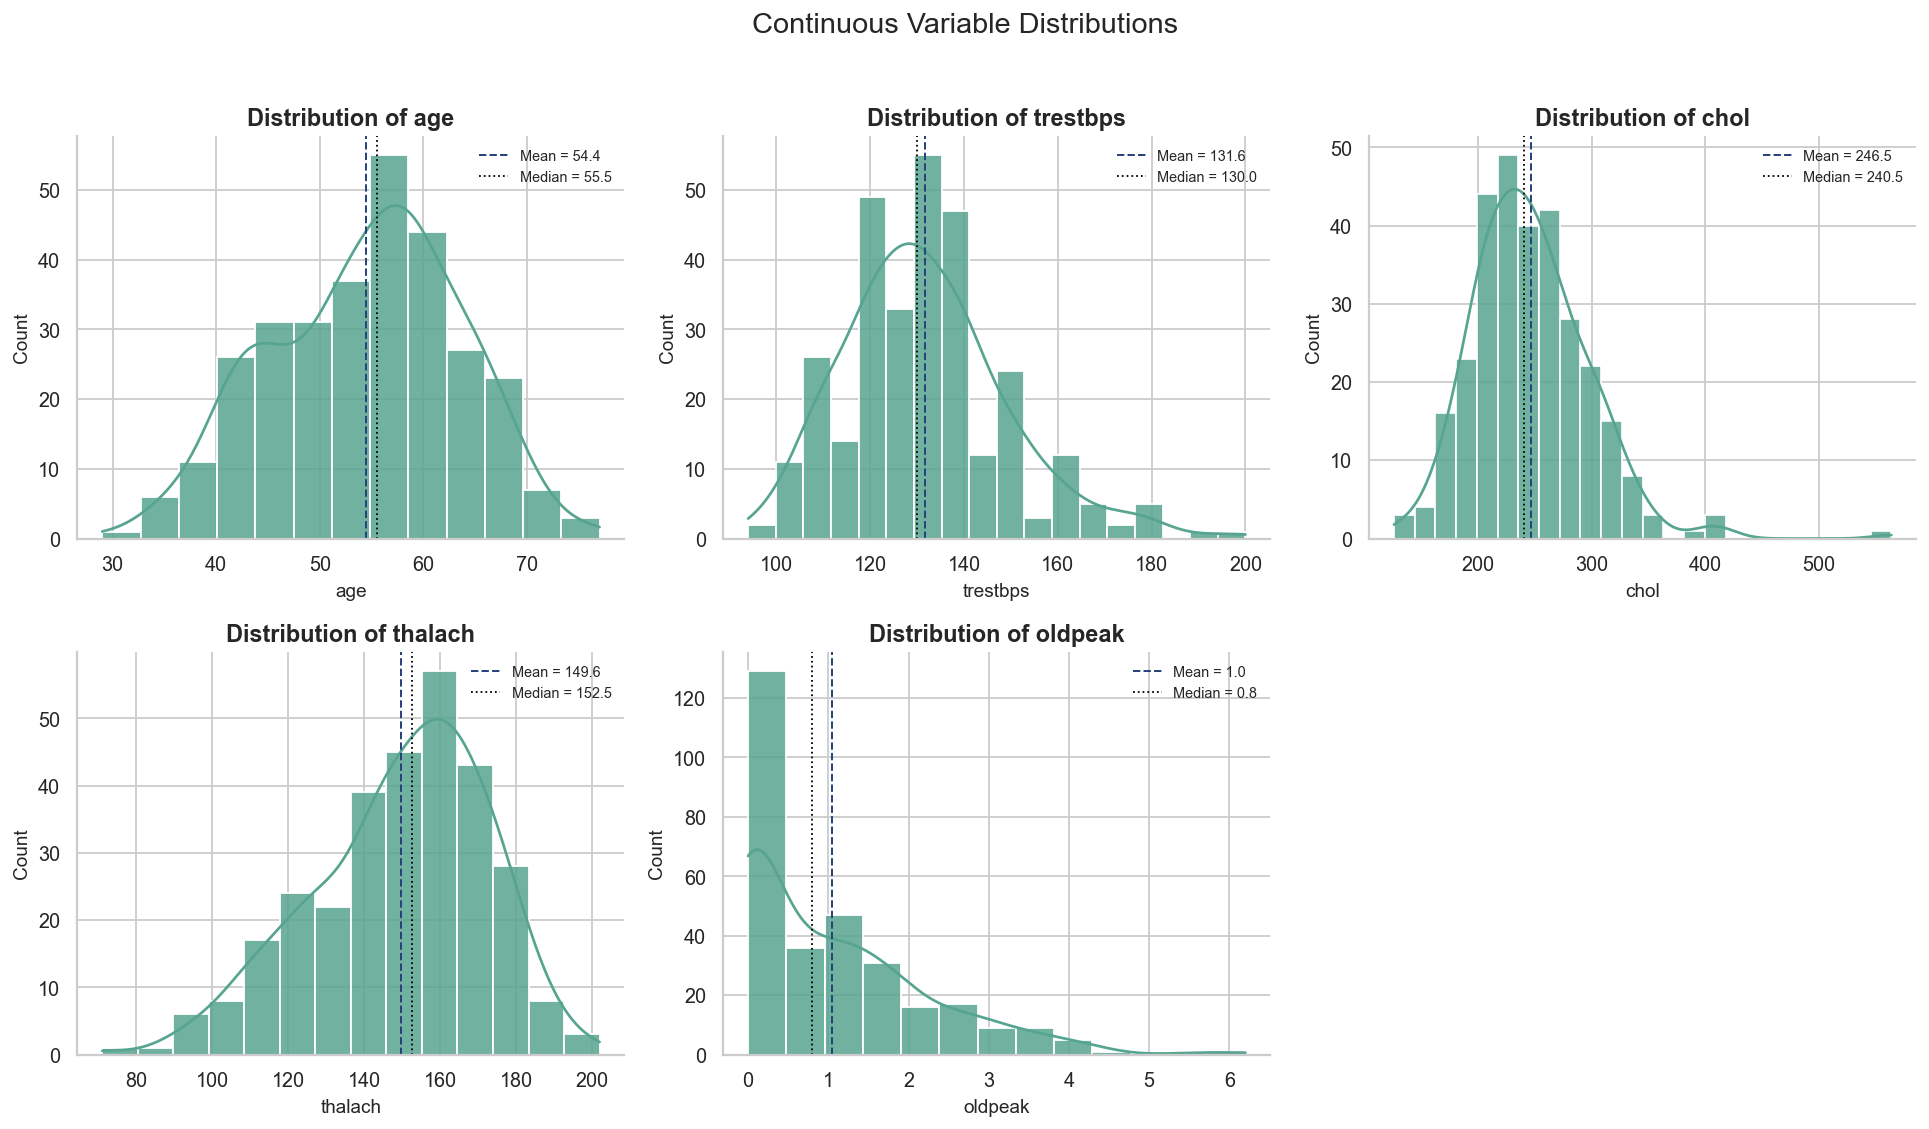

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
axes = axes.ravel()

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df_cleaned, x=col, kde=True, ax=axes[i], color=HEALTHY, edgecolor="white", alpha=0.85)
    mean_val, median_val = df_cleaned[col].mean(), df_cleaned[col].median()
    axes[i].axvline(mean_val, color=DISEASED, linestyle="--", linewidth=1.1, label=f"Mean = {mean_val:.1f}")
    axes[i].axvline(median_val, color="black", linestyle=":", linewidth=1, label=f"Median = {median_val:.1f}")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)

axes[-1].axis("off")
fig.suptitle("Continuous Variable Distributions", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


**Note:** `chol` and `oldpeak` are right-skewed (a small number of patients with very high
values pull the mean above the median), which is why the median is reported alongside the mean
above.

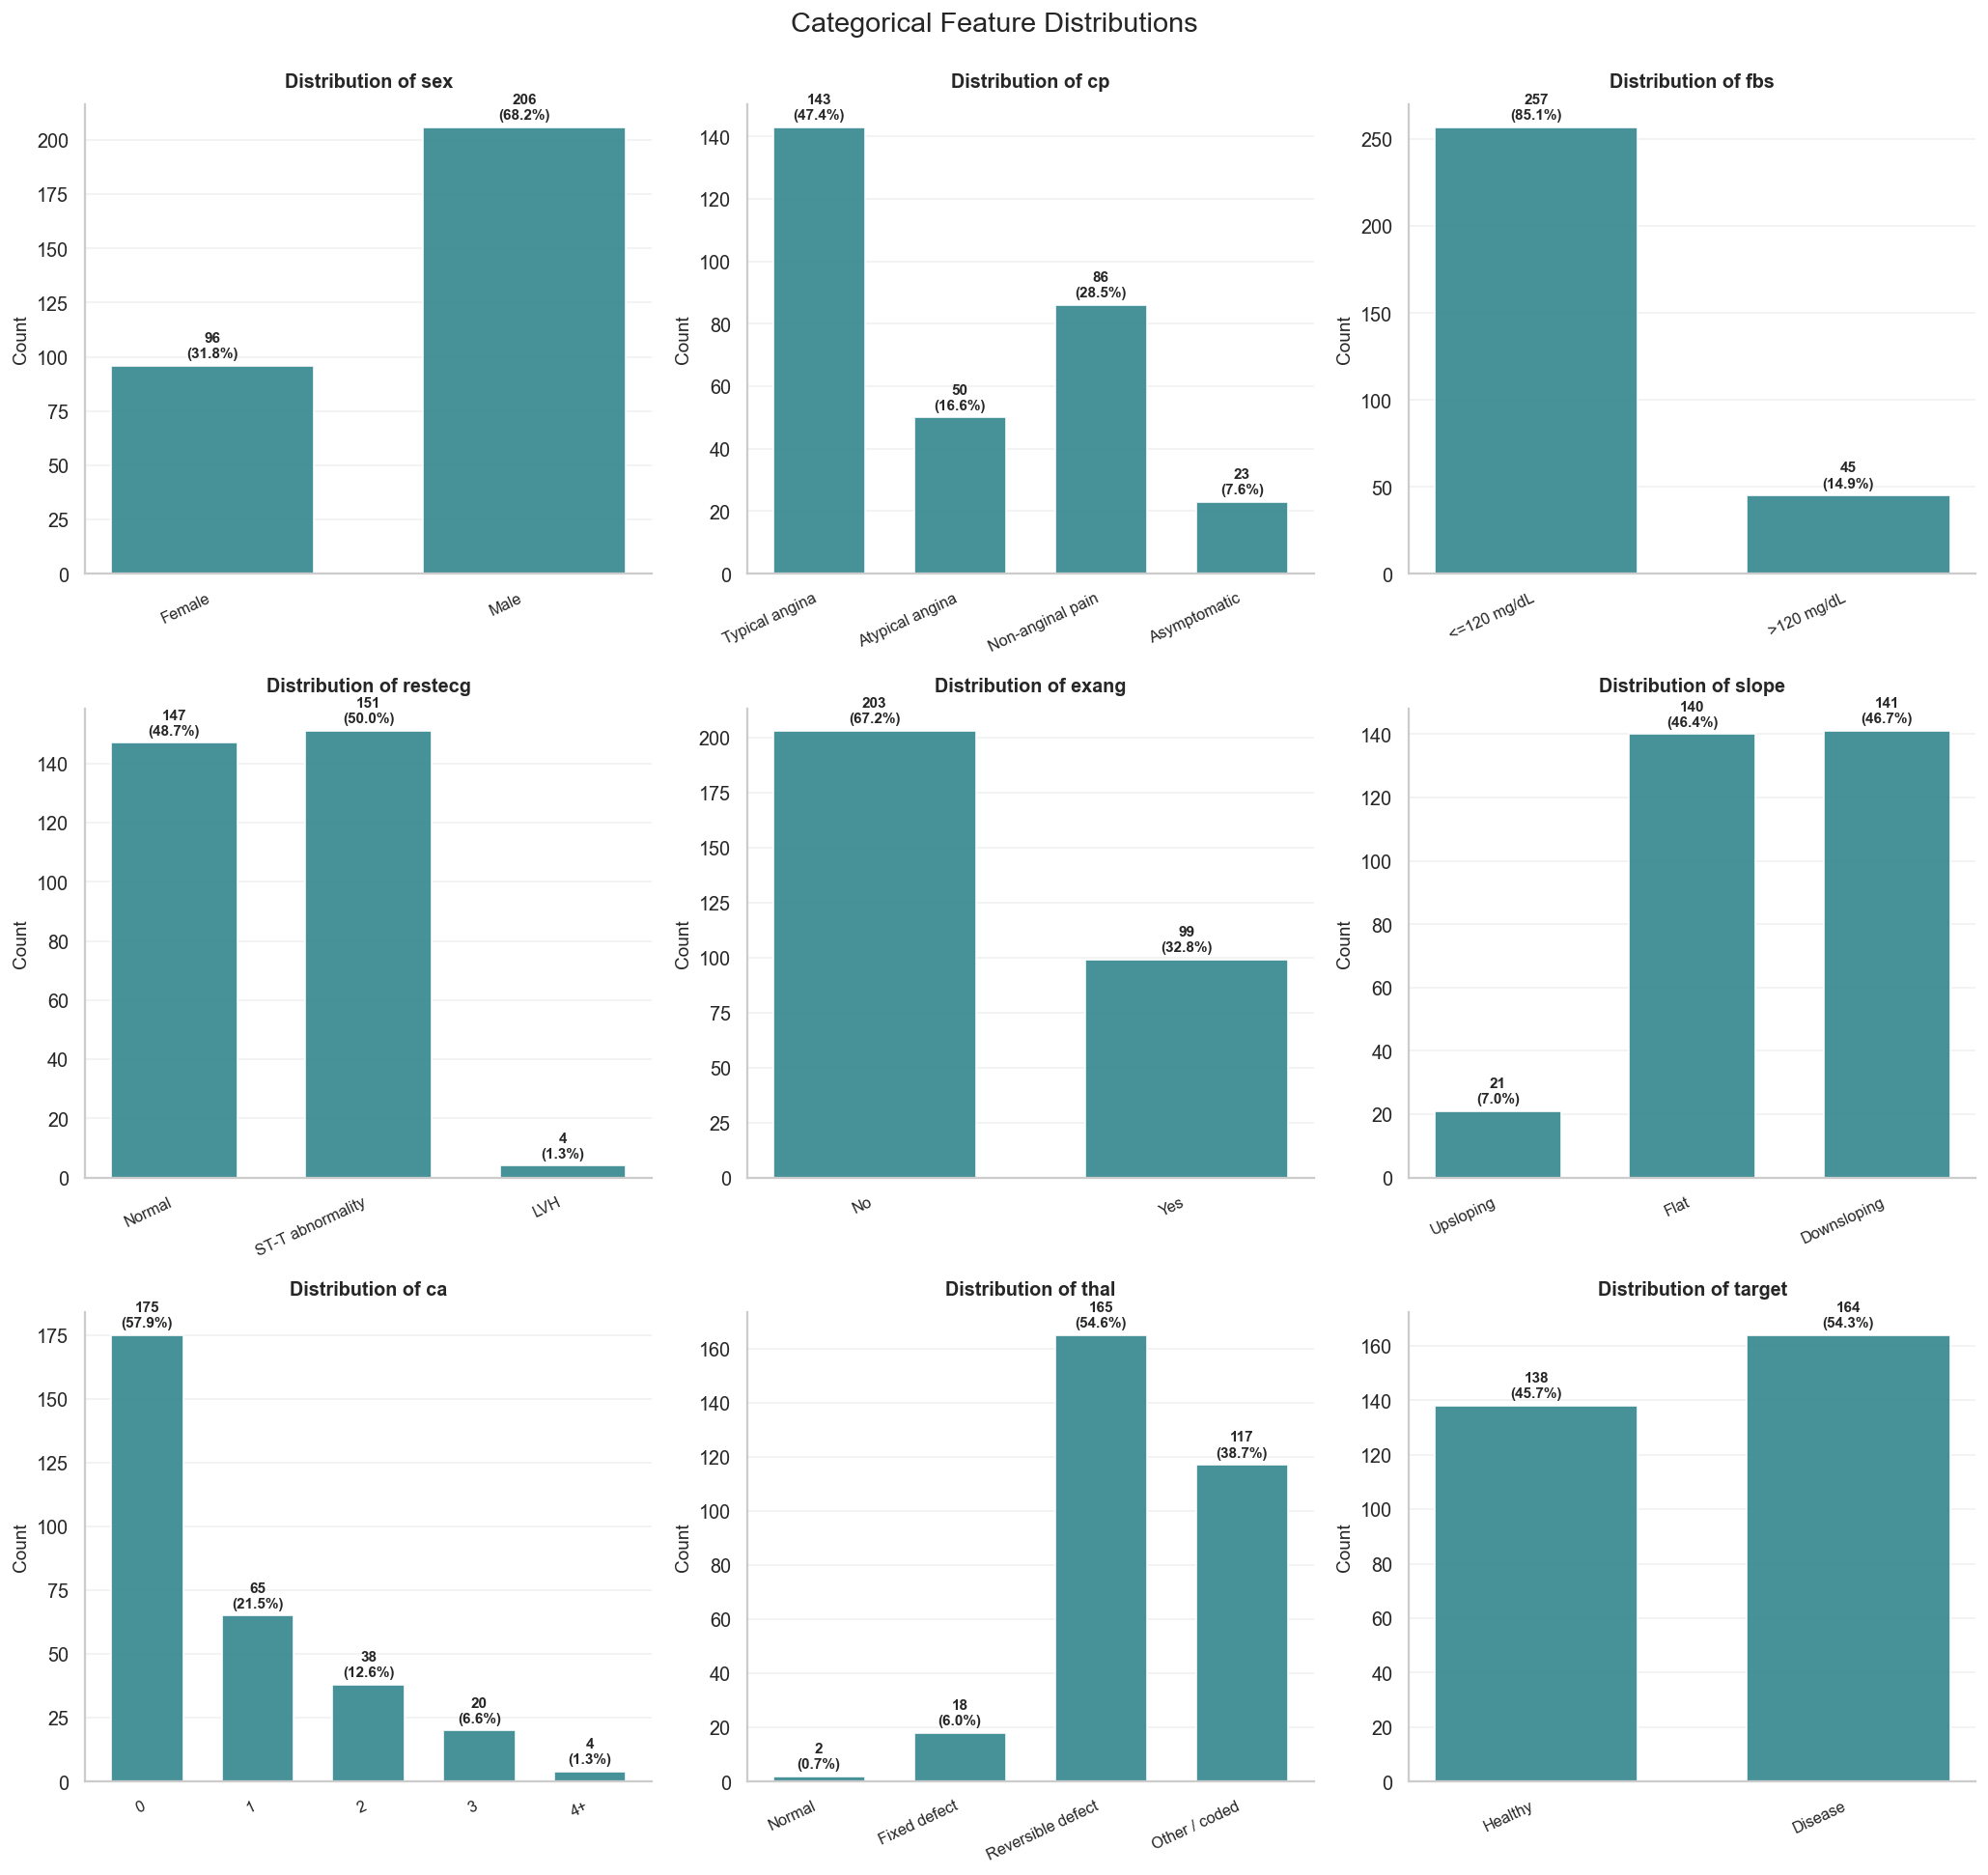

In [29]:
cat_plot_cols = [c for c in categorical_cols + ["target"] if c in plot_df.columns]
fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes = axes.ravel()

for i, col in enumerate(cat_plot_cols):
    counts = df_cleaned[col].value_counts().sort_index()
    col_map = label_maps.get(col, {})
    tick_labels = [col_map.get(v, str(v)) for v in counts.index]
    ax = axes[i]

    bars = ax.bar(range(len(counts)), counts.values, color=SEQ_PALETTE[4], width=0.65, alpha=0.9)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(tick_labels, rotation=25, ha="right", fontsize=9)
    ax.bar_label(bars, labels=[f"{v}\n({v / len(df_cleaned) * 100:.1f}%)" for v in counts.values],
                 padding=3, fontsize=8.5, fontweight="bold")

    ax.set_title(f"Distribution of {col}", fontsize=11, pad=10)
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

for j in range(len(cat_plot_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle("Categorical Feature Distributions", fontsize=16, y=0.995)
fig.tight_layout()
plt.show()


**Note:** the cohort skews male (~68%) and most patients have zero major vessels blocked
(`ca` = 0). Every bar above uses the same neutral color deliberately — this chart is only about
frequency, not disease status, so it doesn't borrow the healthy/diseased color coding used
later.

## 6. Outlier Detection (IQR Method)

Potential outliers are identified with the standard **1.5×IQR rule**. They are reported and
visualized, but not removed automatically.

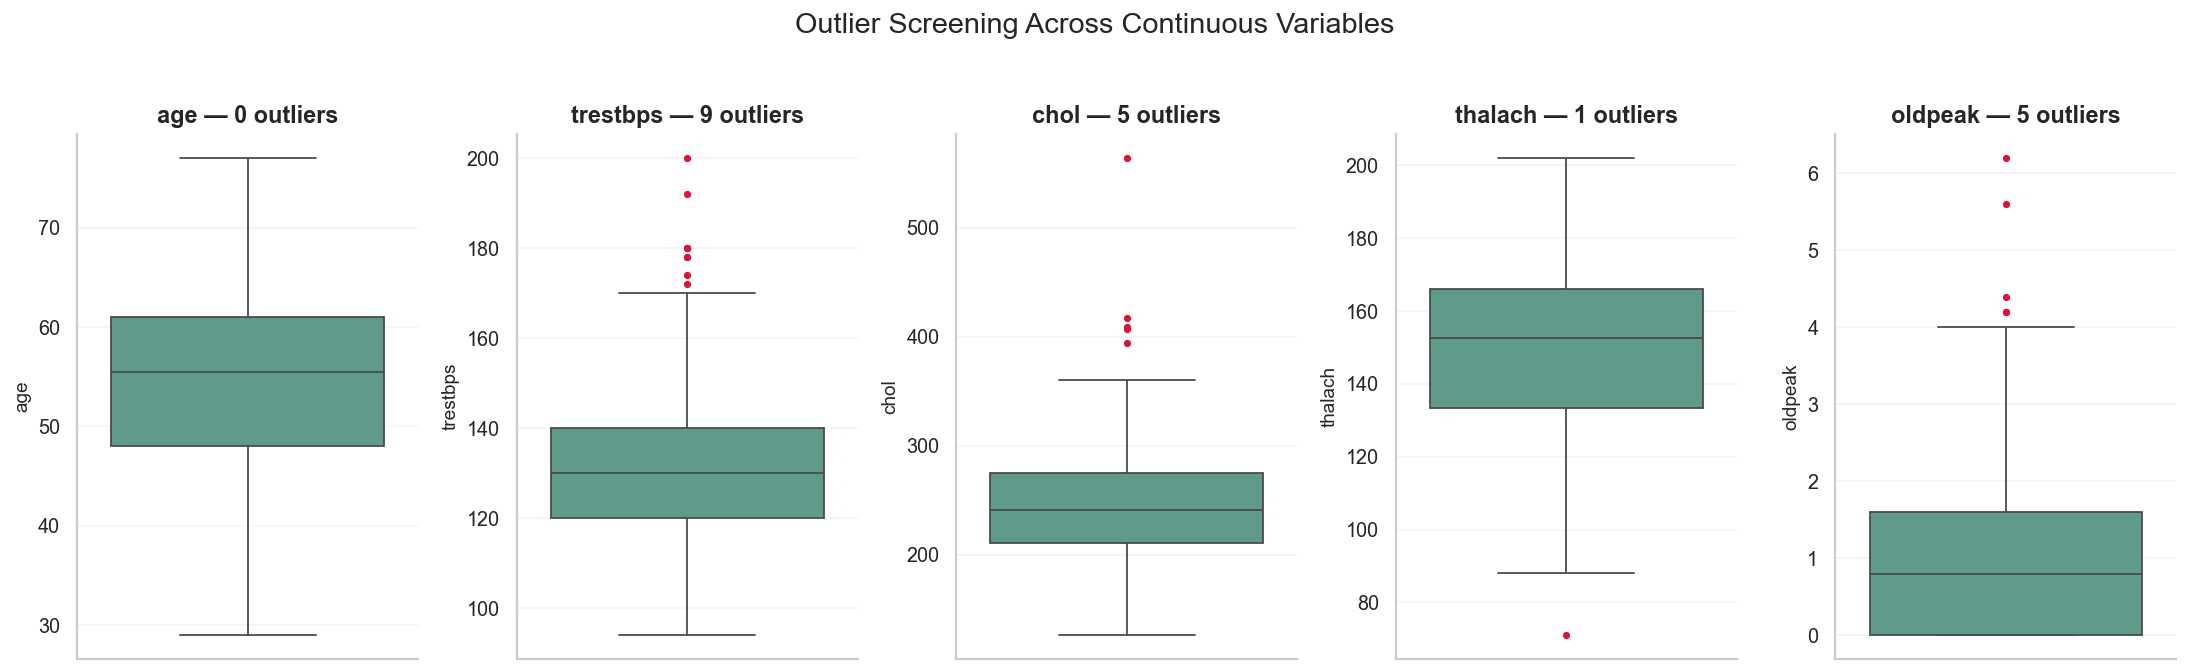

,Variable,Outliers,Outlier_%
1,trestbps,9,2.98
2,chol,5,1.66
4,oldpeak,5,1.66
3,thalach,1,0.33
0,age,0,0.00


In [12]:
outlier_rows = []
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(17, 5))

for ax, col in zip(axes, continuous_cols):
    q1, q3 = df_cleaned[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((df_cleaned[col] < lower) | (df_cleaned[col] > upper)).sum())
    outlier_rows.append({"Variable": col, "Outliers": n_outliers, "Outlier_%": n_outliers / len(df_cleaned) * 100})

    sns.boxplot(data=df_cleaned, y=col, color=HEALTHY, fliersize=3, ax=ax,
                flierprops={"markerfacecolor": "crimson", "markeredgecolor": "crimson"})
    ax.set_title(f"{col} — {n_outliers} outliers")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.2)

outlier_summary = pd.DataFrame(outlier_rows).sort_values("Outliers", ascending=False)
fig.suptitle("Outlier Screening Across Continuous Variables", fontsize=16, y=1.03)
fig.tight_layout()
plt.show()
outlier_summary


**Decision rule:** an IQR flag is a screening signal, not a deletion rule. In a clinical
dataset, unusually high blood pressure or cholesterol may represent real patient variation
rather than bad data.

## 7. Target Analysis

The target is checked separately because class balance directly affects how later predictive
models should be evaluated.

In [13]:
target_summary = (
    plot_df["target_label"]
    .value_counts()
    .rename_axis("Disease Status")
    .to_frame("Count")
    .assign(Percentage=lambda x: x["Count"] / len(plot_df) * 100)
)
target_summary


,Count,Percentage
Disease Status,,
Disease,164,54.30
Healthy,138,45.70


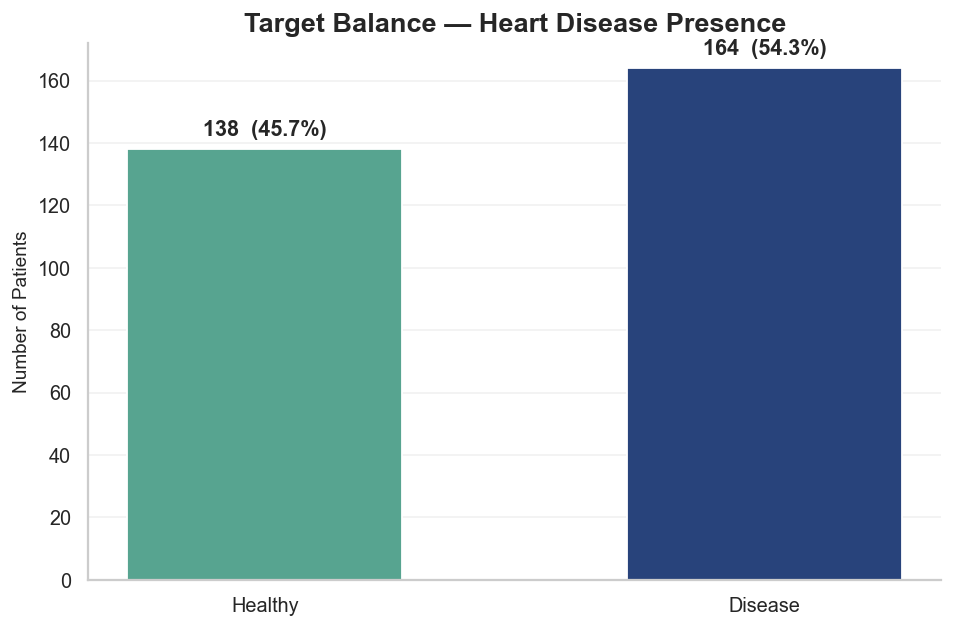

In [30]:
counts = plot_df["target_label"].value_counts().reindex(["Healthy", "Disease"])

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(counts.index, counts.values, color=[HEALTHY, DISEASED], width=0.55)
ax.bar_label(bars, labels=[f"{v}  ({v / len(plot_df) * 100:.1f}%)" for v in counts.values],
             padding=5, fontweight="bold")
ax.set_title("Target Balance — Heart Disease Presence", fontsize=15)
ax.set_ylabel("Number of Patients")
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


**Note:** the class distribution is fairly balanced (54.3% disease vs. 45.7% healthy),
which is favorable for classification modeling and means no resampling (e.g. SMOTE) is
required.

## 8. Bivariate Analysis

### Age vs. Blood Pressure & Cholesterol (with clinical reference thresholds)

Colored by disease status, with standard clinical cut-offs marked as horizontal reference
lines.

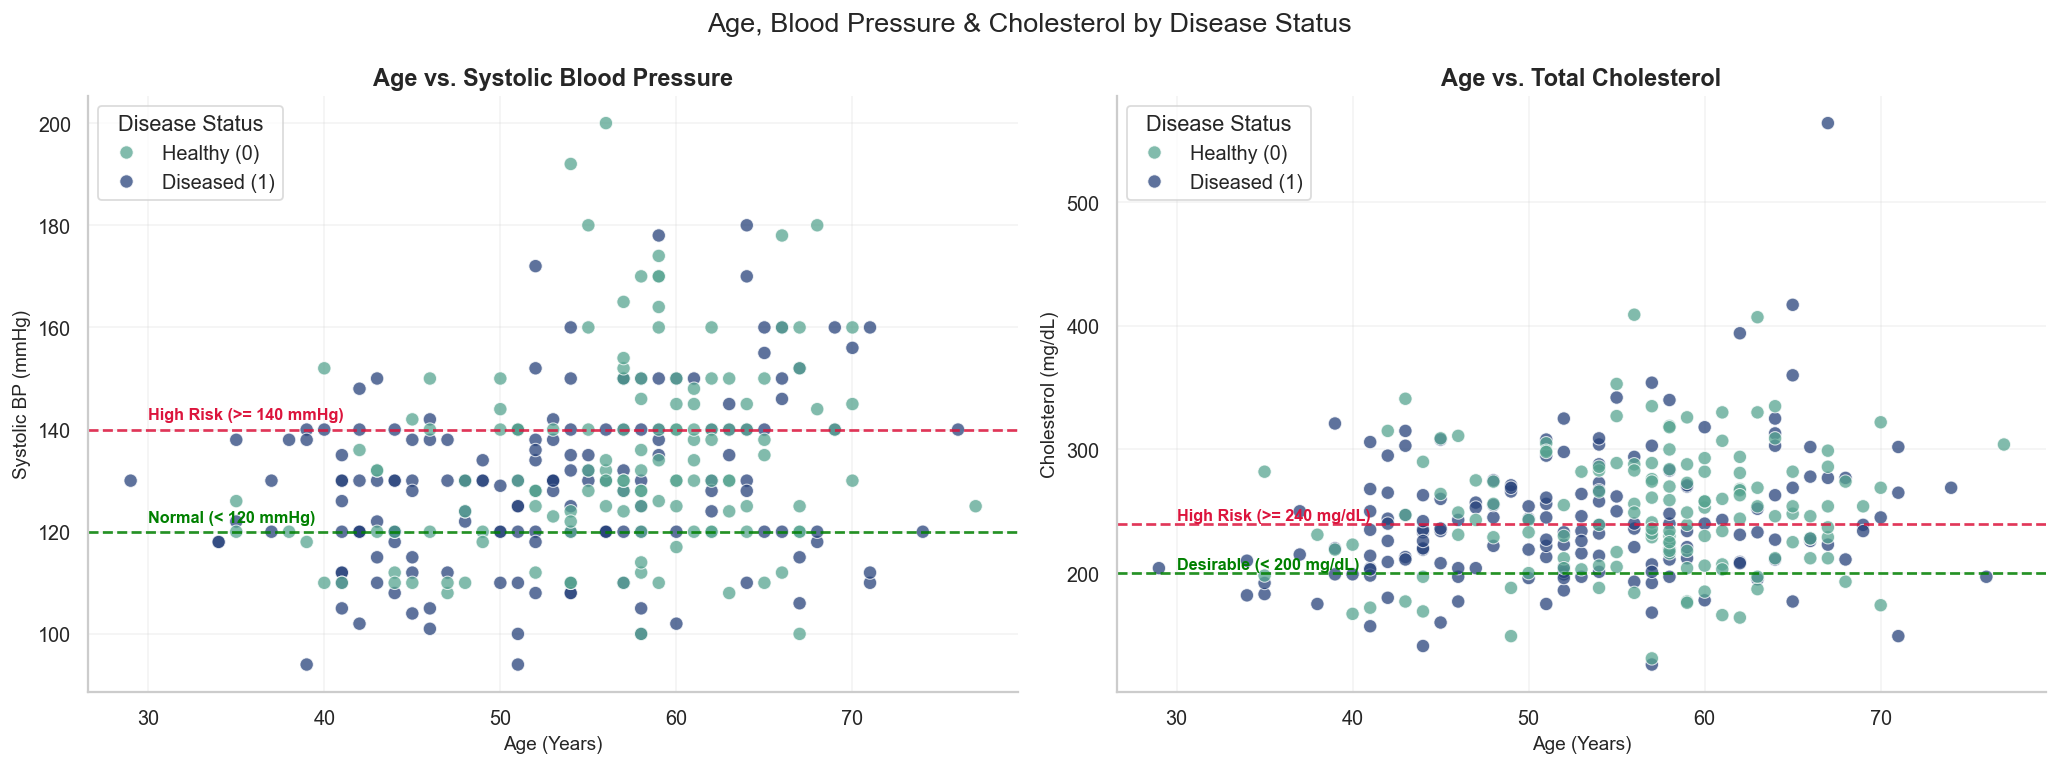

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_cleaned, x="age", y="trestbps", hue="target", hue_order=[0, 1],
                 palette=TARGET_PALETTE, alpha=0.75, s=55, ax=axes[0])
axes[0].axhline(120, color="green", linestyle="--", linewidth=1.5, alpha=0.85)
axes[0].axhline(140, color="crimson", linestyle="--", linewidth=1.5, alpha=0.85)
min_age = df_cleaned["age"].min()
axes[0].text(min_age + 1, 122, "Normal (< 120 mmHg)", color="green", fontsize=9, fontweight="bold")
axes[0].text(min_age + 1, 142, "High Risk (>= 140 mmHg)", color="crimson", fontsize=9, fontweight="bold")
axes[0].set_title("Age vs. Systolic Blood Pressure")
axes[0].set_xlabel("Age (Years)")
axes[0].set_ylabel("Systolic BP (mmHg)")

sns.scatterplot(data=df_cleaned, x="age", y="chol", hue="target", hue_order=[0, 1],
                 palette=TARGET_PALETTE, alpha=0.75, s=55, ax=axes[1])
axes[1].axhline(200, color="green", linestyle="--", linewidth=1.5, alpha=0.85)
axes[1].axhline(240, color="crimson", linestyle="--", linewidth=1.5, alpha=0.85)
axes[1].text(min_age + 1, 203, "Desirable (< 200 mg/dL)", color="green", fontsize=9, fontweight="bold")
axes[1].text(min_age + 1, 243, "High Risk (>= 240 mg/dL)", color="crimson", fontsize=9, fontweight="bold")
axes[1].set_title("Age vs. Total Cholesterol")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("Cholesterol (mg/dL)")

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], ["Healthy (0)", "Diseased (1)"], title="Disease Status",
              loc="upper left", frameon=True, facecolor="white", edgecolor="lightgray")
    ax.grid(alpha=0.2)

fig.suptitle("Age, Blood Pressure & Cholesterol by Disease Status", fontsize=15)
fig.tight_layout()
plt.show()


**Note:** the reference lines are included for contextual interpretation and do not
represent diagnostic thresholds for heart disease.

### Continuous Variables by Disease Status

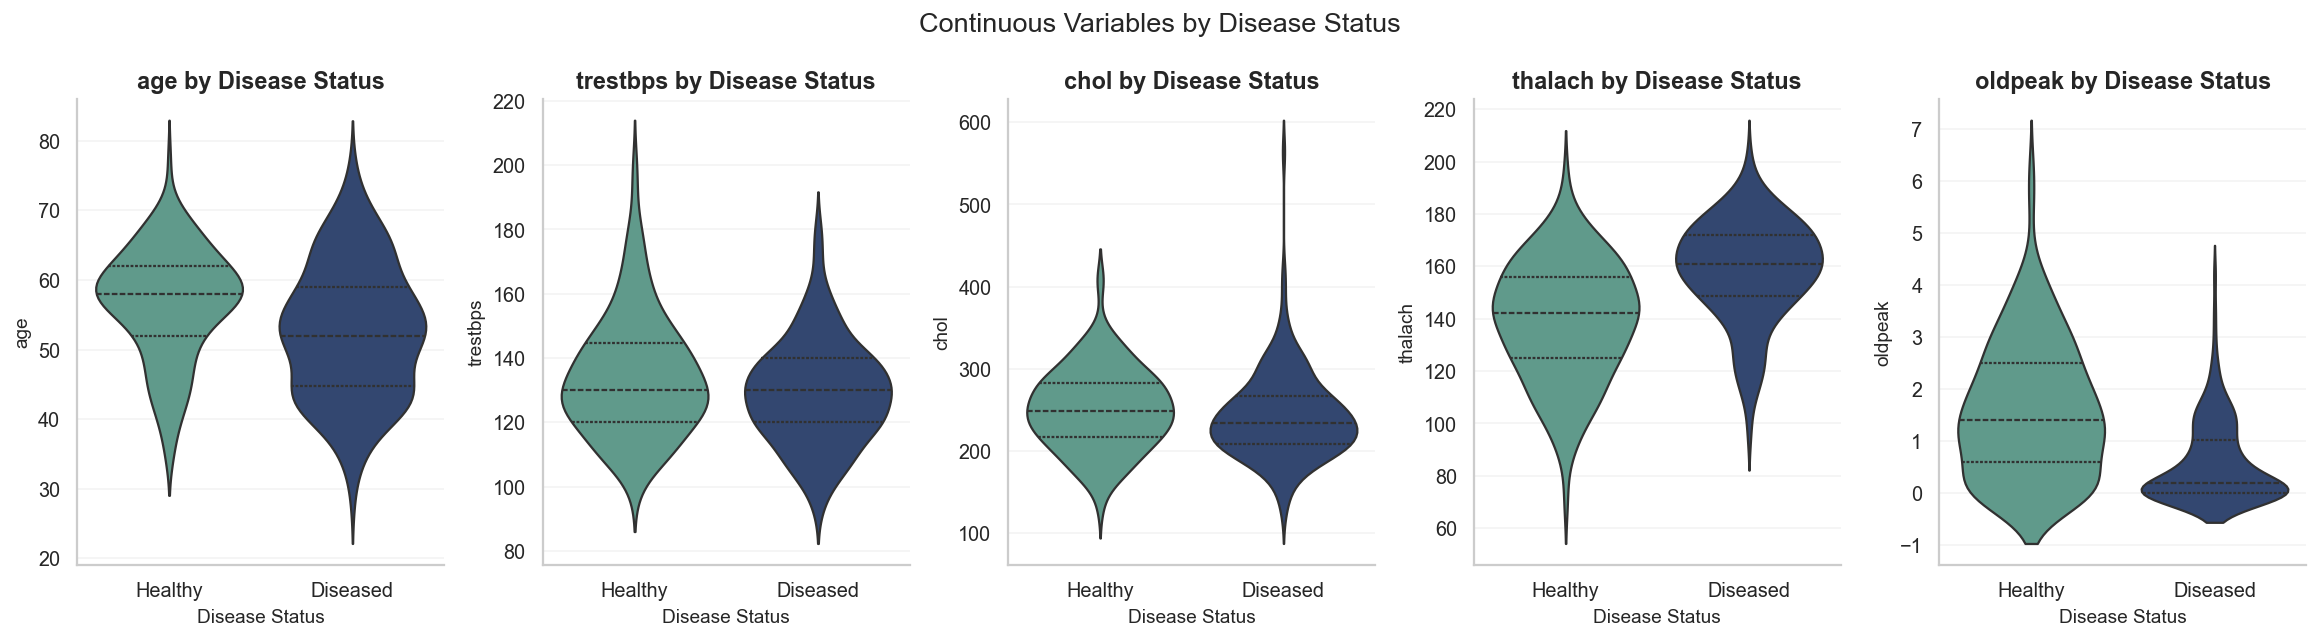

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(continuous_cols):
    sns.violinplot(data=df_cleaned, x="target", y=col, hue="target", hue_order=[0, 1],
                    palette=TARGET_PALETTE, legend=False, ax=axes[i], inner="quartile")
    axes[i].set_title(f"{col} by Disease Status")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Healthy", "Diseased"])
    axes[i].set_xlabel("Disease Status")
    axes[i].grid(axis="y", alpha=0.2)
    axes[i].grid(axis="x", visible=False)

fig.suptitle("Continuous Variables by Disease Status", fontsize=15)
fig.tight_layout()
plt.show()


**Note:** `thalach` (max heart rate) tends to be higher in diseased patients while
`oldpeak` tends to be lower for healthy ones — both line up with the correlation ranking in
Section 10.

### Categorical Variables vs. Disease Rate

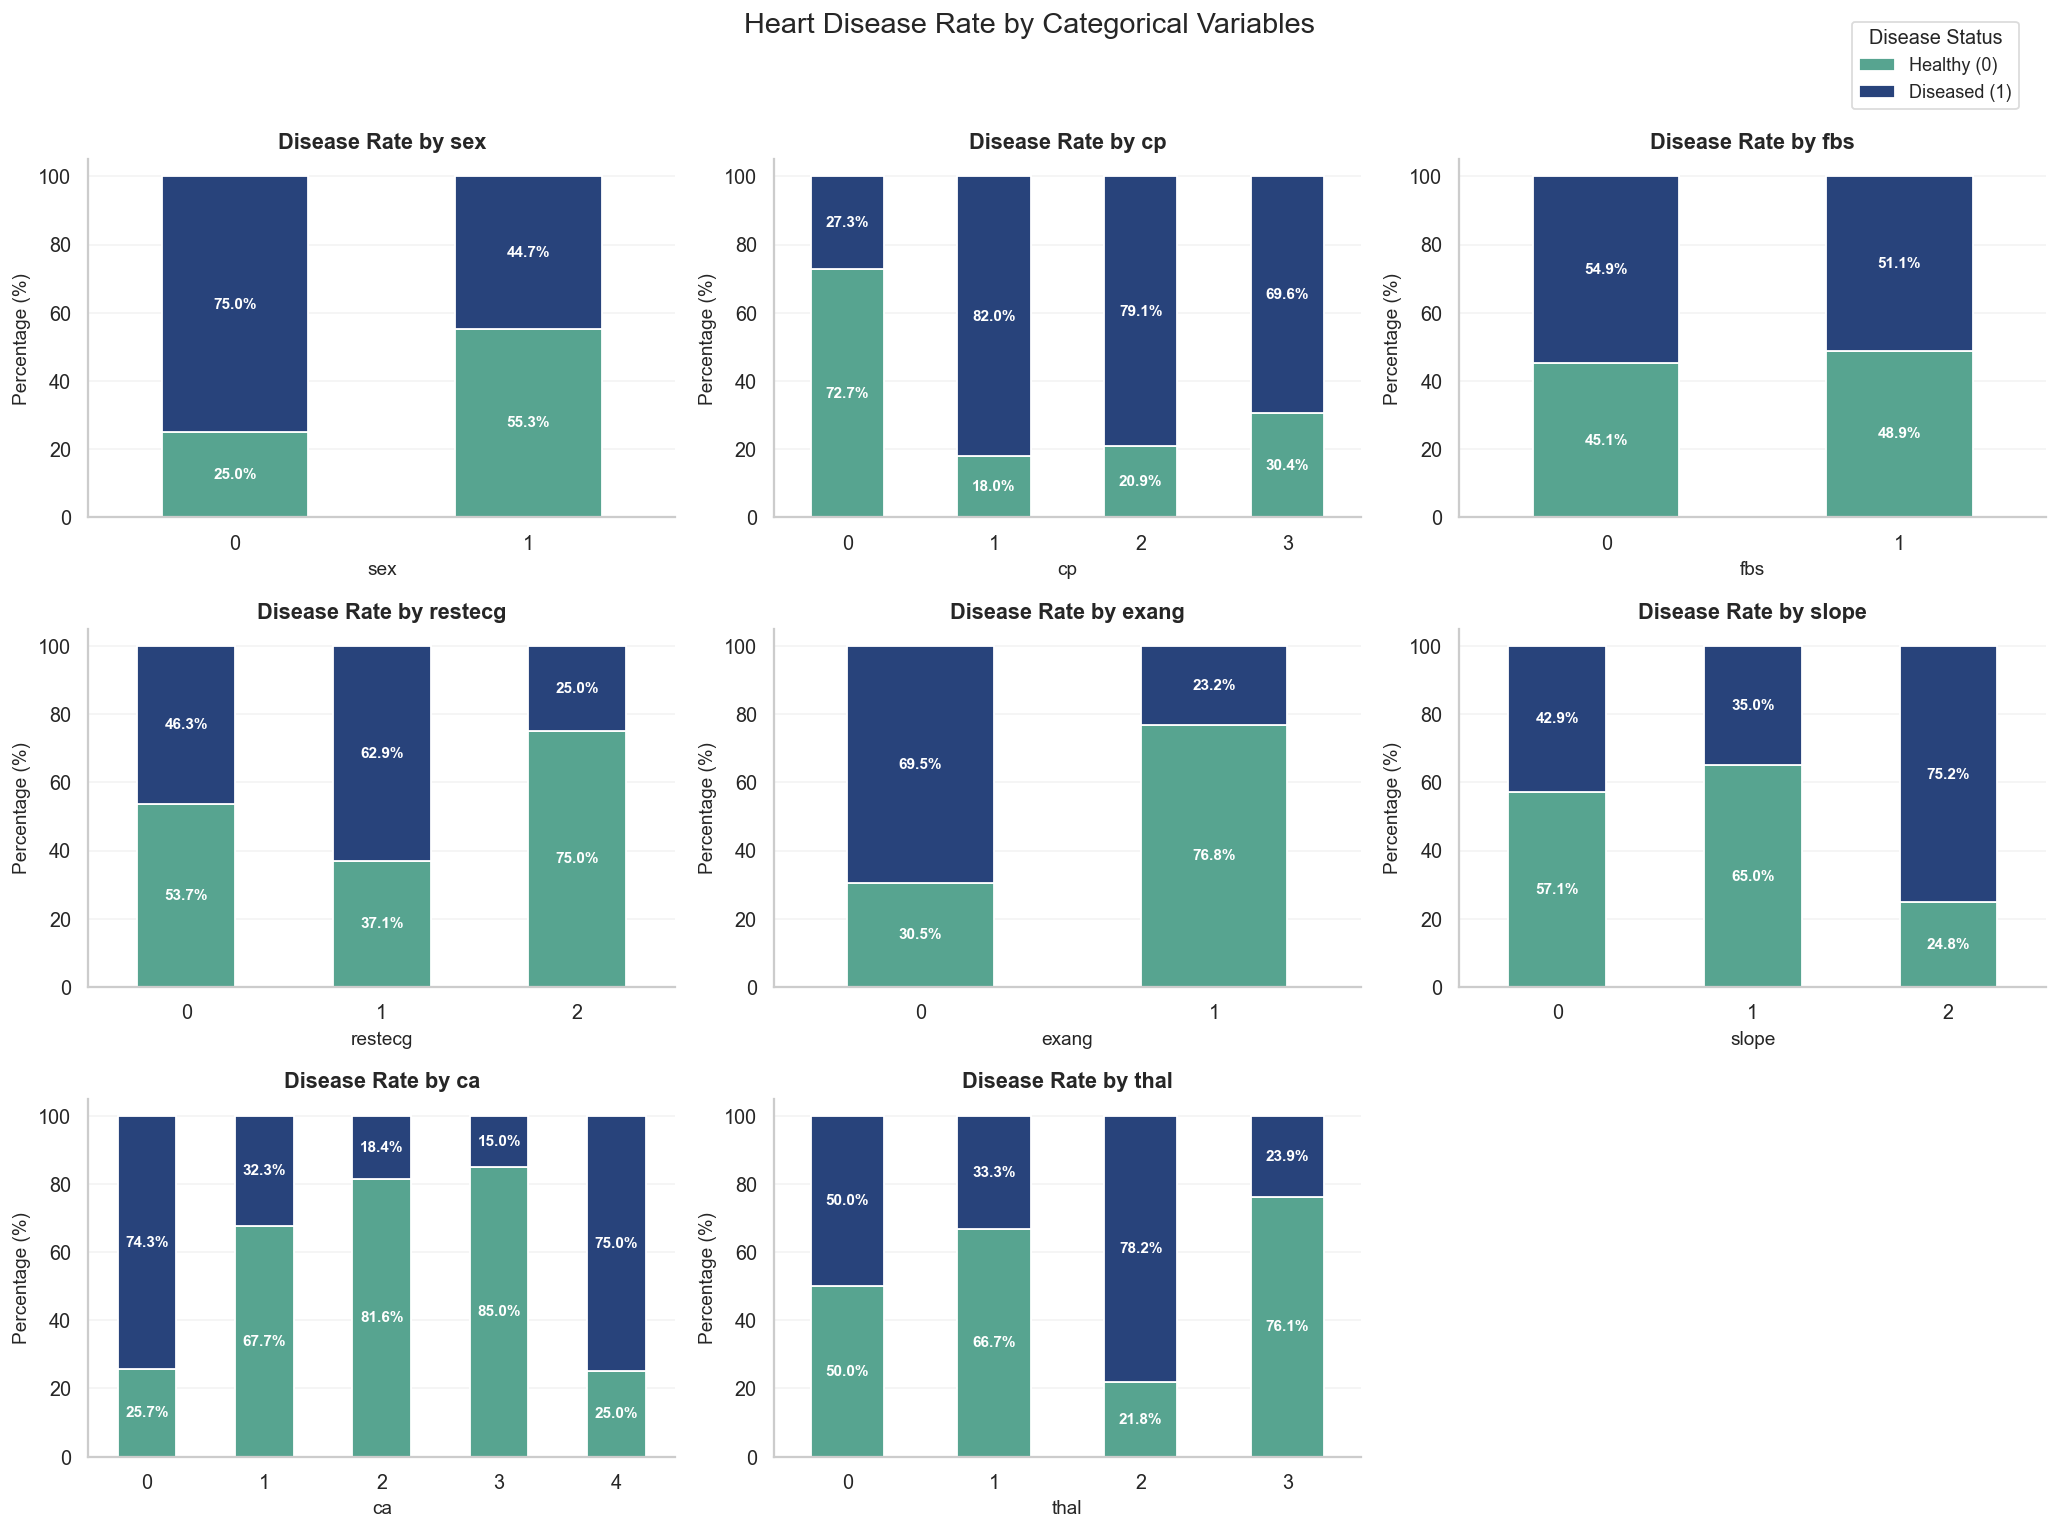

In [ ]:
cat_cols_no_target = [c for c in categorical_cols if c != "target"]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols_no_target):
    ct = pd.crosstab(df_cleaned[col], df_cleaned["target"], normalize="index") * 100

    for target_val in [0, 1]:
        if target_val not in ct.columns:
            ct[target_val] = 0.0
    ct = ct[[0, 1]].rename(columns={0: "Healthy (0)", 1: "Diseased (1)"})

    ct.plot(kind="bar", stacked=True, ax=axes[i], color=[HEALTHY, DISEASED], legend=False, rot=0)
    for container in axes[i].containers:
        axes[i].bar_label(container, labels=[f"{v:.1f}%" if v > 4 else "" for v in container.datavalues],
                           label_type="center", color="white", fontweight="bold", fontsize=8.5)

    axes[i].set_title(f"Disease Rate by {col}", fontsize=12)
    axes[i].set_ylabel("Percentage (%)")
    axes[i].set_ylim(0, 105)
    axes[i].grid(axis="y", alpha=0.2)
    axes[i].grid(axis="x", visible=False)

for j in range(len(cat_cols_no_target), len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Disease Status", loc="upper right", bbox_to_anchor=(0.98, 0.98),
           fontsize=10, title_fontsize=11, frameon=True, facecolor="white", edgecolor="lightgray")
fig.suptitle("Heart Disease Rate by Categorical Variables", fontsize=16, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Disease Rate by Age Group

Age is binned into decade-based groups so the trend is easier to read than in the raw scatter
plot above; bins are aligned with the observed age range in the dataset.

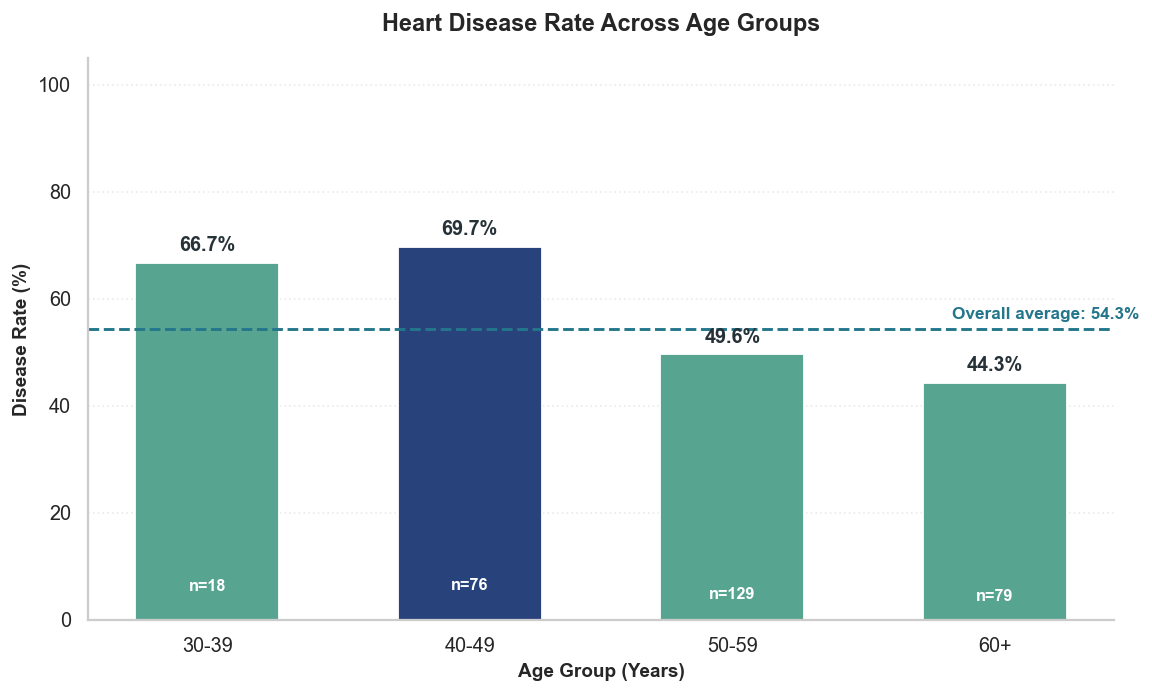

In [18]:
age_bins = [28, 40, 50, 60, 80]
age_labels = ["30-39", "40-49", "50-59", "60+"]
df_cleaned["age_group"] = pd.cut(df_cleaned["age"], bins=age_bins, labels=age_labels, include_lowest=True)

age_stats = df_cleaned.groupby("age_group", observed=True)["target"].agg(
    Rate=lambda x: round(x.mean() * 100, 1), Count="count")
overall_avg = df_cleaned["target"].mean() * 100
max_rate = age_stats["Rate"].max()
bar_colors = [DISEASED if r == max_rate else HEALTHY for r in age_stats["Rate"]]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(age_stats.index.astype(str), age_stats["Rate"], color=bar_colors, width=0.55)

ax.axhline(overall_avg, color=SEQ_PALETTE[5], linestyle="--", linewidth=1.6)
ax.text(len(age_stats) - 0.45, overall_avg + 2, f"Overall average: {overall_avg:.1f}%",
        color=SEQ_PALETTE[5], fontsize=9.5, fontweight="bold", ha="right")

for bar, (_, row) in zip(bars, age_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2.2, f"{row['Rate']:.1f}%",
            ha="center", fontsize=11, fontweight="bold", color="#263238")
    ax.text(bar.get_x() + bar.get_width() / 2, max(bar.get_height() * 0.08, 3), f"n={int(row['Count'])}",
            ha="center", fontsize=9, fontweight="bold", color="white")

ax.set_title("Heart Disease Rate Across Age Groups", pad=15)
ax.set_xlabel("Age Group (Years)", fontweight="bold")
ax.set_ylabel("Disease Rate (%)", fontweight="bold")
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle=":", alpha=0.35)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


## 9. Demographic Subgroup Analysis

So far every breakdown has pooled male and female patients together. Here we check whether
that pooling hides a real difference: does the overall disease rate — and the effect of other
risk factors — look the same for men and women, or not?

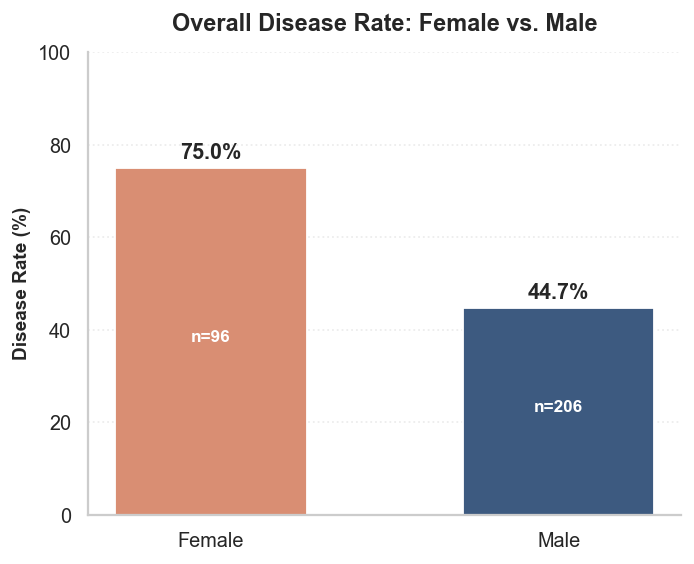

In [19]:
gender_overall = (df_cleaned.assign(sex_label=plot_df["sex_label"])
                   .groupby("sex_label", observed=True)["target"].mean() * 100).round(1)
gender_n = plot_df["sex_label"].value_counts()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(gender_overall.index, gender_overall.values,
              color=[GENDER_PALETTE[g] for g in gender_overall.index], width=0.55)
for bar, label in zip(bars, gender_overall.index):
    height = gender_overall[label]
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2, f"{height:.1f}%", ha="center", fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2, height / 2, f"n={gender_n[label]}",
            ha="center", fontsize=9.5, fontweight="bold", color="white")
ax.set_title("Overall Disease Rate: Female vs. Male", pad=12)
ax.set_ylabel("Disease Rate (%)", fontweight="bold")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle=":", alpha=0.35)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


**Note:** women show a notably higher disease rate here than men, despite being the
smaller subgroup. This is worth flagging rather than over-interpreting — with fewer female
records, the estimate has wider uncertainty, and this dataset is not necessarily
representative of the general population. The breakdown below checks whether this gap holds
consistently across other risk factors, or is concentrated in a few categories.

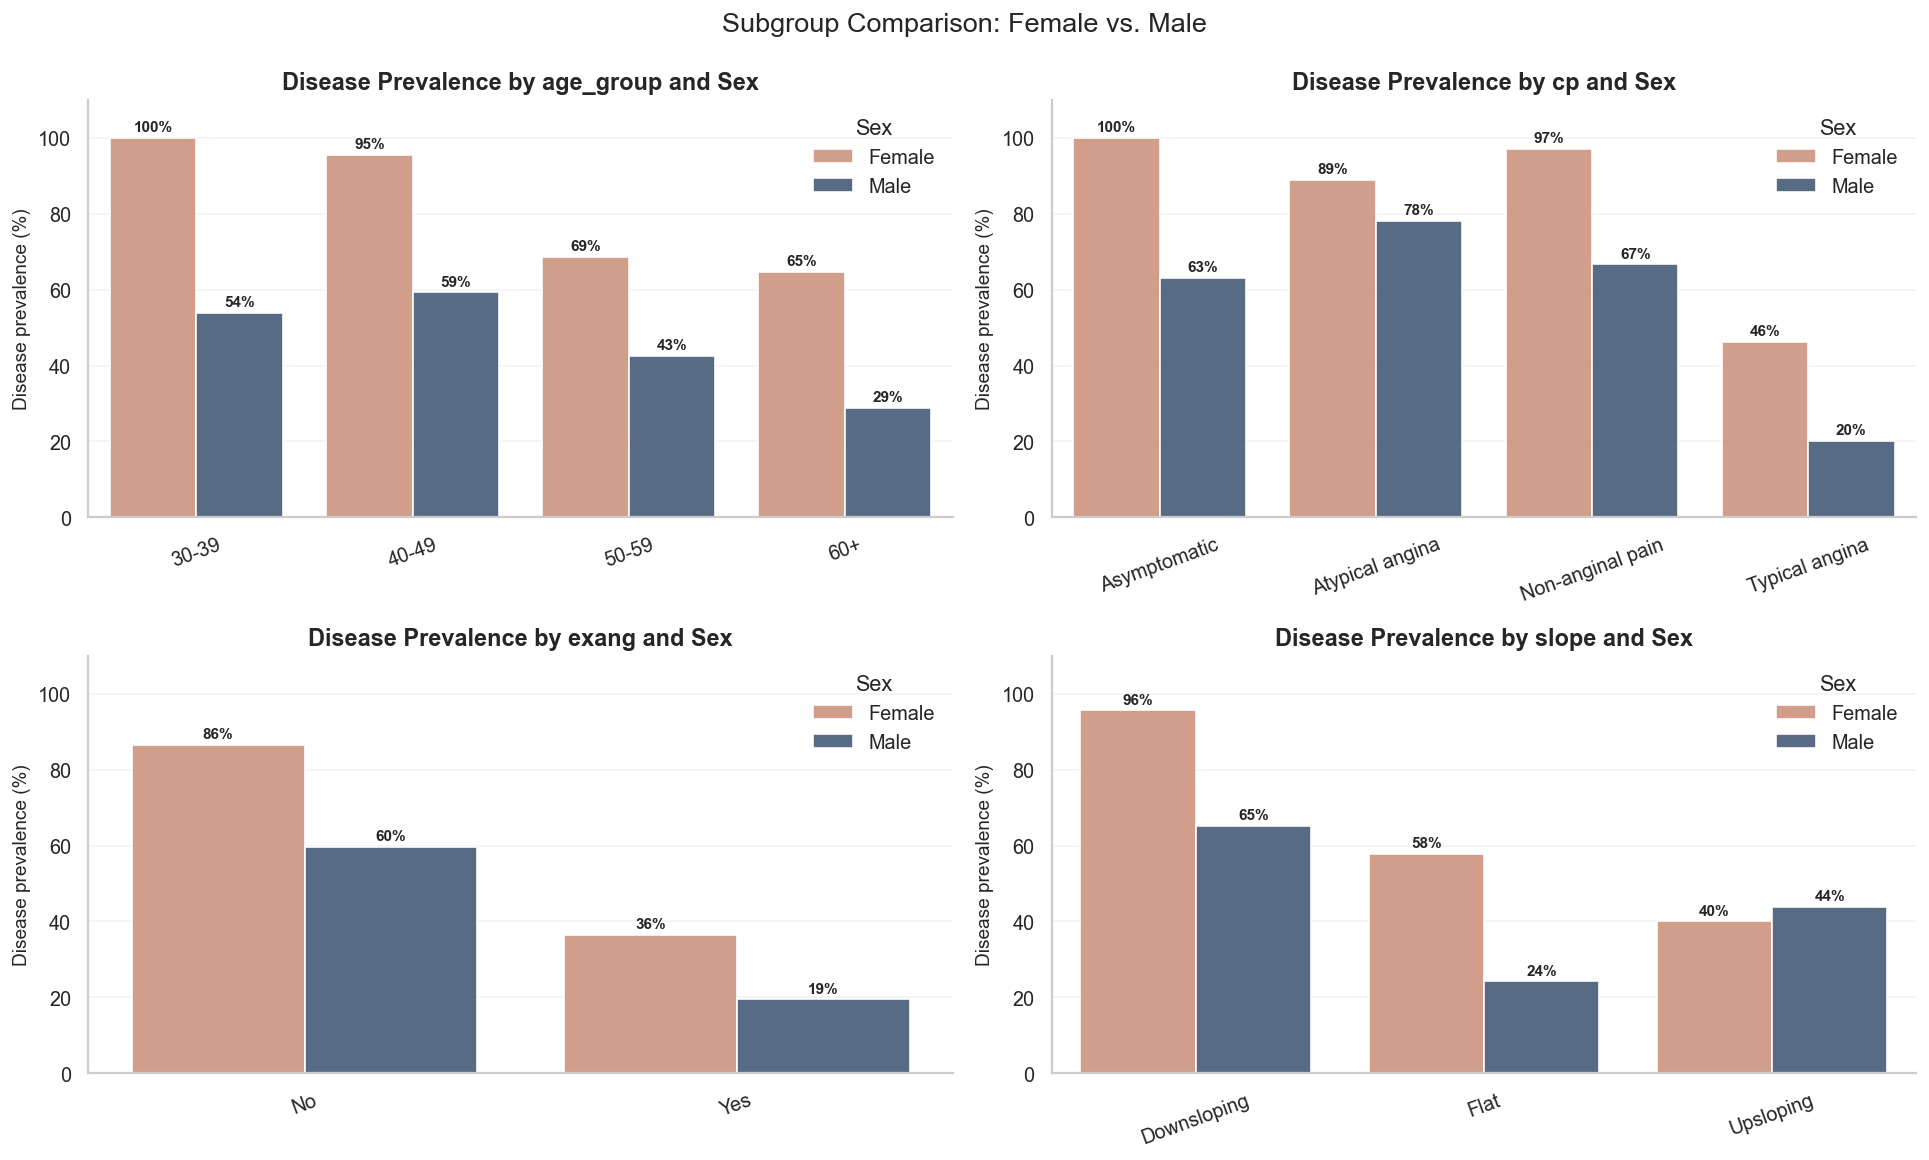

In [20]:
plot_df["age_group"] = df_cleaned["age_group"]
subgroup_features = ["age_group", "cp", "exang", "slope"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, subgroup_features):
    feature_col = f"{col}_label" if f"{col}_label" in plot_df.columns else col
    tmp = (plot_df.groupby([feature_col, "sex_label"], observed=True)["target"]
           .mean().mul(100).reset_index(name="rate"))

    sns.barplot(data=tmp, x=feature_col, y="rate", hue="sex_label", hue_order=["Female", "Male"],
                palette=GENDER_PALETTE, ax=ax, edgecolor="white", alpha=0.9)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f%%", padding=2, fontsize=8.5, fontweight="bold")

    ax.set_title(f"Disease Prevalence by {col} and Sex")
    ax.set_xlabel("")
    ax.set_ylabel("Disease prevalence (%)")
    ax.set_ylim(0, 110)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.2)
    ax.grid(axis="x", visible=False)
    ax.legend(title="Sex", loc="upper right")

fig.suptitle("Subgroup Comparison: Female vs. Male", fontsize=15, y=0.99)
fig.tight_layout()
plt.show()


**Note:** the gap is not concentrated in a single feature — women show a higher disease
rate across most chest-pain types, age groups, and activity levels, not just one subgroup. That
strengthens the case that it's a genuine pattern in this dataset rather than an artifact of one
feature, though — as above — the small female sample size still calls for caution before
drawing broader conclusions. `ca` and `thal` are left out of this breakdown since their rarer
categories (see Section 3) would produce unreliable per-subgroup rates.

## 10. Correlation & Association Analysis

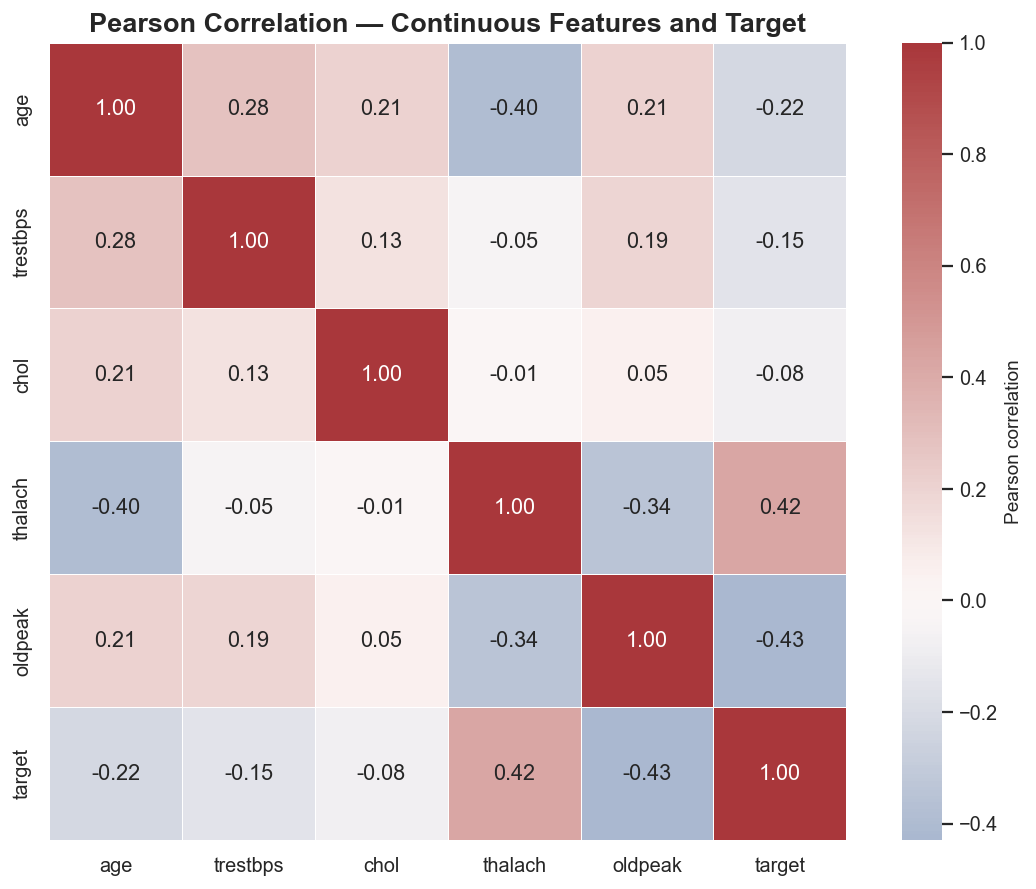

In [21]:
numeric_for_corr = continuous_cols + ["target"]
corr = df_cleaned[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
            linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Pearson Correlation — Continuous Features and Target", fontsize=15)
plt.tight_layout()
plt.show()


Pearson correlation only applies to continuous variables — running it on numerically
coded categories (like `thal` or `cp`) would imply a linear ordering that isn't really there.
Categorical associations are measured separately in Section 11 using Cramér's V, and the two
are brought together in one ranked view right after that.

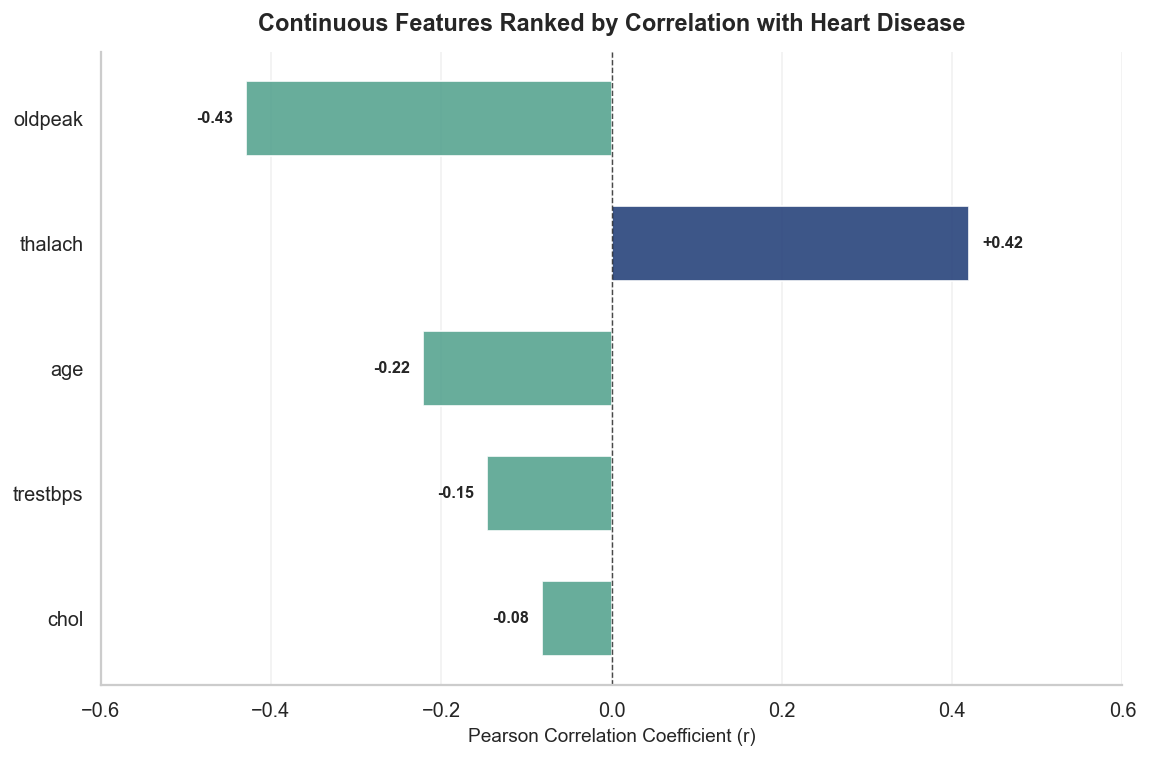

In [22]:
# Ranked by strength (largest magnitude at the top of the chart).
target_corr = corr["target"].drop("target").sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [DISEASED if v > 0 else HEALTHY for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=bar_colors, height=0.6, alpha=0.9)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)

for bar, val in zip(bars, target_corr.values):
    offset = 0.015 if val >= 0 else -0.015
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2, f"{val:+.2f}",
            va="center", ha="left" if val >= 0 else "right", fontsize=9, fontweight="bold")

ax.set_title("Continuous Features Ranked by Correlation with Heart Disease", pad=12)
ax.set_xlabel("Pearson Correlation Coefficient (r)")
ax.set_xlim(-0.6, 0.6)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()


## 11. Statistical Significance & Effect Size

**Welch's t-test** is used for continuous variables and **Chi-square + Cramér's V** for
categorical variables. P-values indicate statistical evidence; effect size quantifies how
strong the relationship actually is.

In [31]:
#tests for continuous variables
continuous_tests = []
for col in continuous_cols:
    group0 = df_cleaned.loc[df_cleaned["target"] == 0, col]
    group1 = df_cleaned.loc[df_cleaned["target"] == 1, col]
    t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=False)
    continuous_tests.append({
        "Variable": col,
        "Mean_Healthy": group0.mean(),
        "Mean_Diseased": group1.mean(),
        "Mean_Difference": group1.mean() - group0.mean(),
        "p_value": p_value,
        "Significant_(p<0.05)": "Yes" if p_value < 0.05 else "No",
    })

continuous_test_df = pd.DataFrame(continuous_tests).sort_values("p_value")
continuous_test_df.round(4)


,Variable,Mean_Healthy,Mean_Diseased,Mean_Difference,p_value,Significant_(p<0.05)
3,thalach,139.10,158.38,19.28,0.00,Yes
4,oldpeak,1.59,0.59,-1.00,0.00,Yes
0,age,56.60,52.59,-4.02,0.00,Yes
1,trestbps,134.40,129.25,-5.15,0.01,Yes
2,chol,251.09,242.64,-8.45,0.16,No


In [ ]:
# Bias-corrected Cramer's V: a 0-1 effect size for two categorical
#     variables, analogous to |correlation| but valid for non-numeric codes.

def cramers_v(table):
    chi2 = stats.chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)
    return np.sqrt(phi2corr / max(min(kcorr - 1, rcorr - 1), 1e-12))


categorical_tests = []
for col in categorical_cols:
    table = pd.crosstab(df_cleaned[col], df_cleaned["target"])
    chi2, p_value, dof, _ = stats.chi2_contingency(table)
    categorical_tests.append({
        "Variable": col, "Chi2": chi2, "p_value": p_value,
        "Cramers_V": cramers_v(table),
        "Significant_(p<0.05)": "Yes" if p_value < 0.05 else "No",
    })

categorical_test_df = pd.DataFrame(categorical_tests).sort_values("Cramers_V", ascending=False)
categorical_test_df.round(4)


,Variable,Chi2,p_value,Cramers_V,Significant_(p<0.05)
7,thal,84.61,0.00,0.52,Yes
1,cp,80.98,0.00,0.51,Yes
6,ca,73.69,0.00,0.48,Yes
4,exang,55.46,0.00,0.43,Yes
5,slope,46.89,0.00,0.39,Yes
0,sex,23.08,0.00,0.27,Yes
3,restecg,9.73,0.01,0.16,Yes
2,fbs,0.09,0.76,0.00,No


### Combined Feature Ranking

Sections 10 and 11 rank continuous and categorical features *separately*, which makes it hard
to answer a simple question: **across every feature type, what matters most overall?** This
chart puts continuous |correlation| and categorical Cramér's V on the same 0-1 scale so they
can be compared directly in one place.

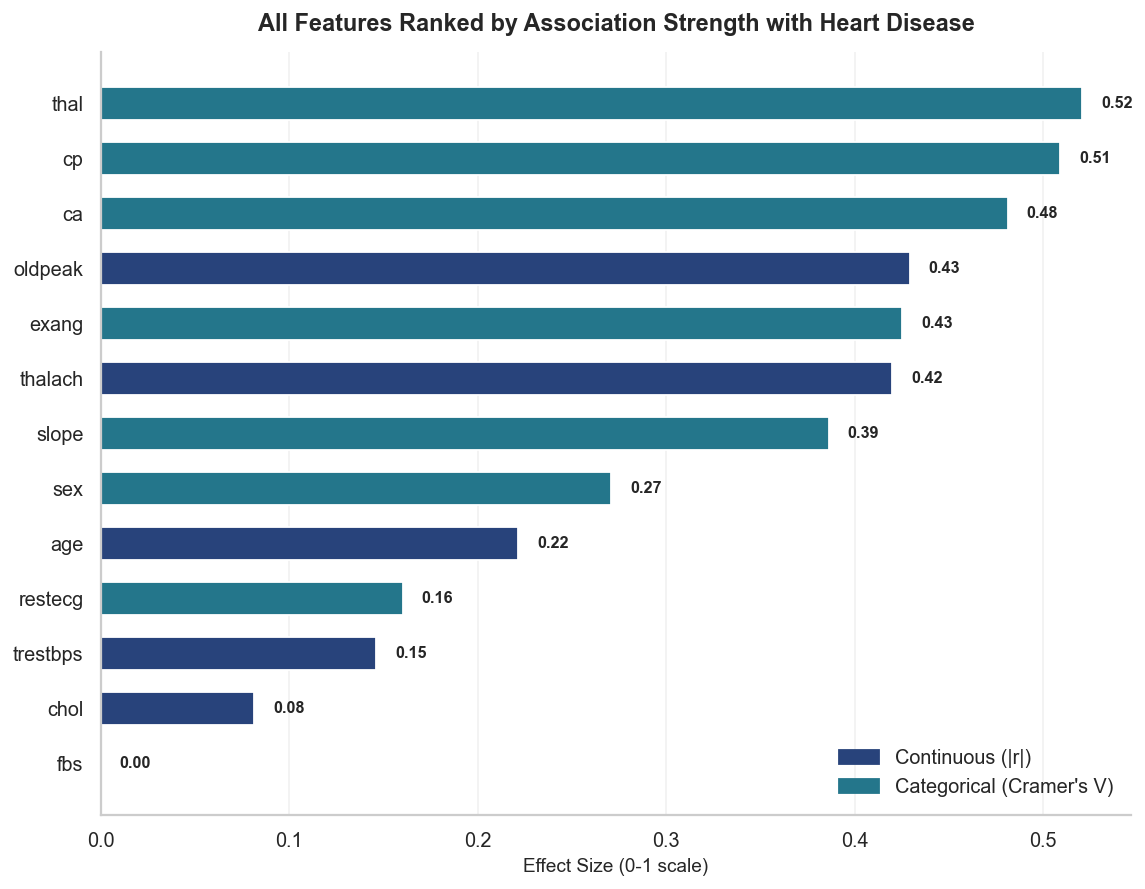

In [25]:
combined_ranking = pd.concat([
    pd.Series({row["Variable"]: abs(row["r"]) for row in
               [{"Variable": v, "r": c} for v, c in corr["target"].drop("target").items()]}, name="Strength")
        .to_frame().assign(Type="Continuous (|r|)"),
    categorical_test_df.set_index("Variable")["Cramers_V"].to_frame("Strength").assign(Type="Categorical (Cramer's V)")
]).reset_index(names="Variable").sort_values("Strength")

fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = [DISEASED if t.startswith("Continuous") else SEQ_PALETTE[5] for t in combined_ranking["Type"]]
ax.barh(combined_ranking["Variable"], combined_ranking["Strength"], color=bar_colors, height=0.6)

for y, (val, vtype) in enumerate(zip(combined_ranking["Strength"], combined_ranking["Type"])):
    ax.text(val + 0.01, y, f"{val:.2f}", va="center", fontsize=9, fontweight="bold")

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=DISEASED), plt.Rectangle((0, 0), 1, 1, color=SEQ_PALETTE[5])]
ax.legend(legend_handles, ["Continuous (|r|)", "Categorical (Cramer's V)"], loc="lower right")
ax.set_title("All Features Ranked by Association Strength with Heart Disease", pad=12)
ax.set_xlabel("Effect Size (0-1 scale)")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()


### Interpretation Guardrails

- A small p-value supports evidence of an association; it does not measure practical importance.
- Cramér's V is used to rank categorical associations by effect size, on the same 0-1 scale as |r|.
- Multiple hypothesis tests are performed, so p-values should be interpreted as exploratory rather than definitive evidence.
- None of these tests establishes causality.

## 12. Multivariate Analysis

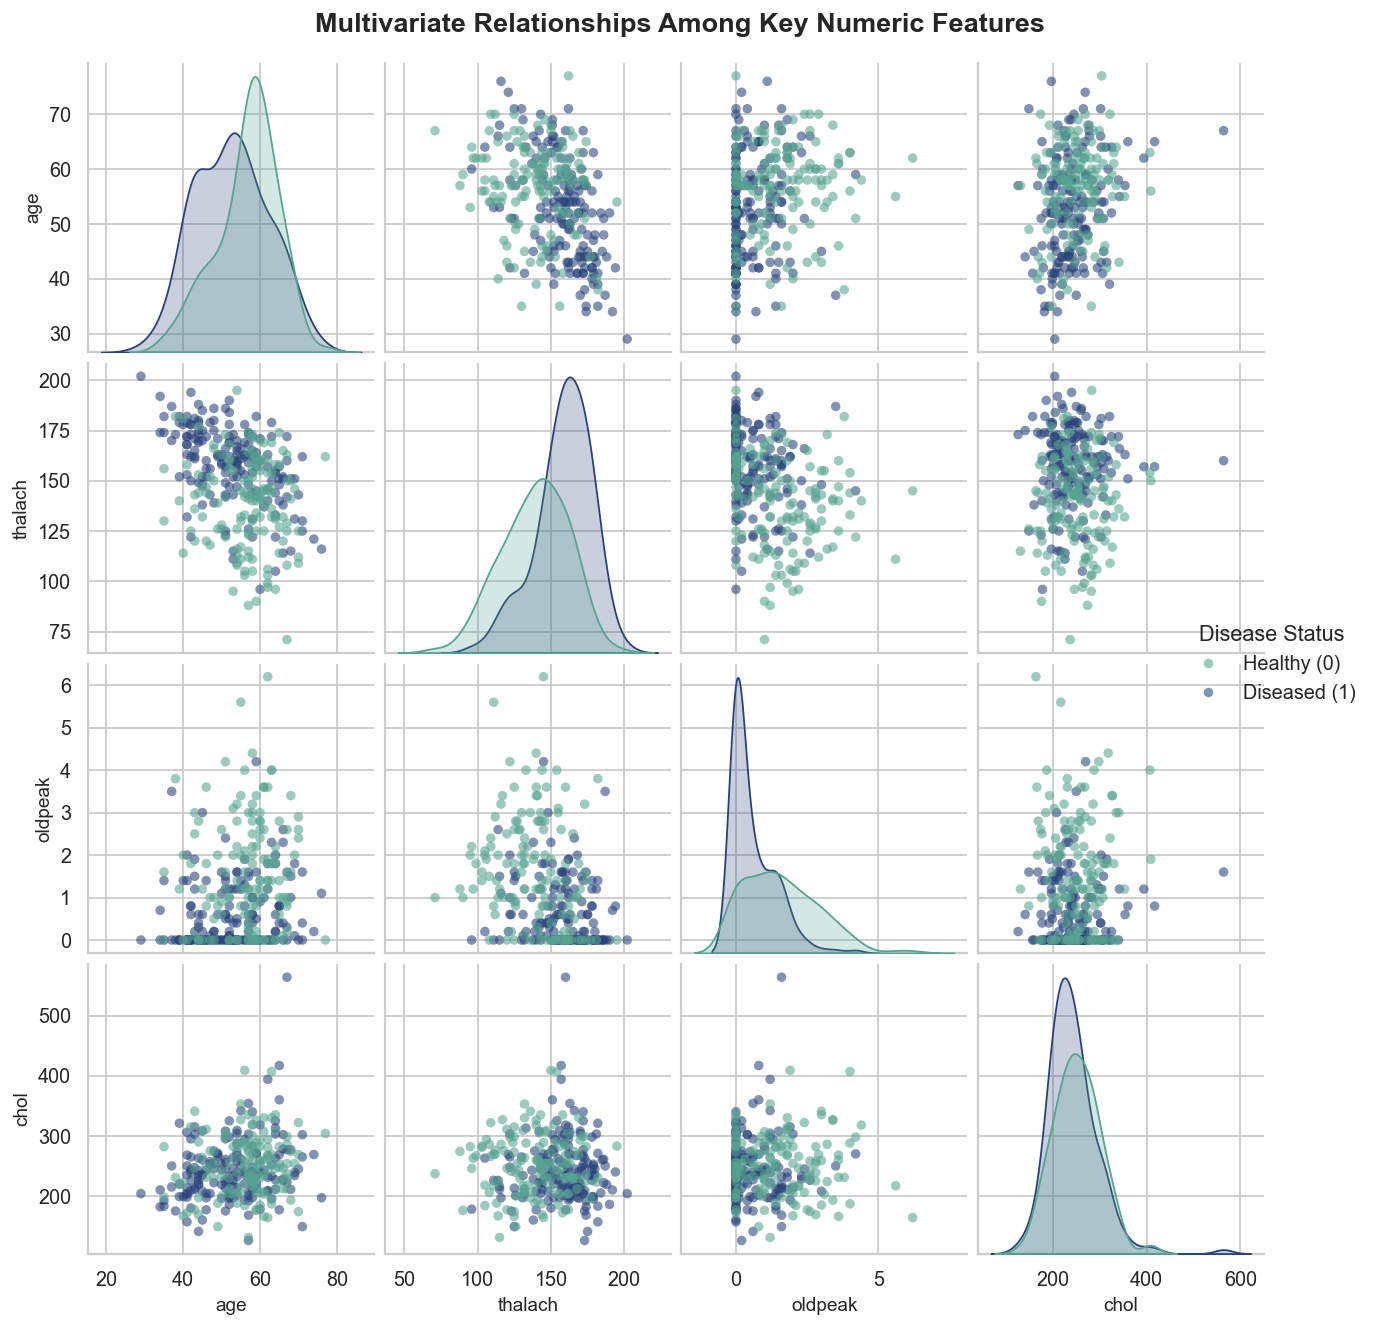

In [ ]:
pair_features = ["age", "thalach", "oldpeak", "chol", "target"]

pair_plot = sns.pairplot(
    plot_df[pair_features],hue="target", palette=TARGET_PALETTE,diag_kind="kde", 
    plot_kws={"alpha": 0.58, "s": 28, "edgecolor": "none"})

for text, label in zip(pair_plot._legend.texts, ["Healthy (0)", "Diseased (1)"]):
    text.set_text(label)

pair_plot._legend.set_title("Disease Status")
pair_plot.fig.suptitle("Multivariate Relationships Among Key Numeric Features", y=1.02, fontsize=15, fontweight="bold")

plt.show()

## 13. Key Findings & Modeling Recommendations

The final interpretation is generated from the analysis outputs above rather than manually
hard-coded, so it remains consistent if the dataset changes.

In [27]:
best_numeric = target_corr.abs().idxmax()
best_numeric_corr = target_corr[best_numeric]
best_cat = categorical_test_df.iloc[0]

largest_mean_gap = (continuous_test_df.assign(abs_gap=lambda x: x["Mean_Difference"].abs())
                     .sort_values("abs_gap", ascending=False).iloc[0])

outlier_counts = {}
for col in continuous_cols:
    q1, q3 = df_cleaned[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df_cleaned[col] < q1 - 1.5 * iqr) | (df_cleaned[col] > q3 + 1.5 * iqr)
    outlier_counts[col] = int(mask.sum())
most_outliers = max(outlier_counts, key=outlier_counts.get)

no_disease_pct = (df_cleaned["target"] == 0).mean() * 100
disease_pct = (df_cleaned["target"] == 1).mean() * 100

print(f"Records analyzed: {len(df_cleaned):,} (after removing {n_duplicates:,} duplicate row(s)).")
print(f"Target balance: {no_disease_pct:.1f}% no disease vs. {disease_pct:.1f}% disease.")
print(f"Strongest continuous target correlation: {best_numeric} (r = {best_numeric_corr:.2f}).")
print(f"Strongest categorical association by Cramer's V: {best_cat['Variable']} (V = {best_cat['Cramers_V']:.2f}).")
print(f"Largest absolute group mean difference among continuous variables: {largest_mean_gap['Variable']} ({largest_mean_gap['Mean_Difference']:.2f}).")
print(f"Most frequently flagged IQR outliers: {most_outliers} ({outlier_counts[most_outliers]} observations).")


Records analyzed: 302 (after removing 1 duplicate row(s)).
Target balance: 45.7% no disease vs. 54.3% disease.
Strongest continuous target correlation: oldpeak (r = -0.43).
Strongest categorical association by Cramer's V: thal (V = 0.52).
Largest absolute group mean difference among continuous variables: thalach (19.28).
Most frequently flagged IQR outliers: trestbps (9 observations).


### Takeaways

- **Data quality:** duplicate rows are removed reproducibly; missing values and implausible zeros are explicitly audited.
- **EDA clarity:** coded categorical variables are translated into human-readable labels for every visualization.
- **Target relationships:** continuous features are evaluated with Pearson correlation, while categorical features use Cramér's V — avoiding misleading numeric-code correlations — and both are combined into one ranked view in Section 11.
- **Statistical support:** Welch's t-tests, Chi-square tests, and effect sizes provide evidence beyond visual inspection.
- **Subgroup awareness:** a gender-based breakdown (Section 9) checks whether pooled results hide a real difference between men and women.


> **Scope note:** this dataset is suitable for demonstrating an analytics workflow, but it
> should not be treated as a clinical decision-support system without external validation,
> domain expertise, and rigorous prospective evaluation.